# Diabetes Patient Readmission Risk & Support-Programme Business Case
### Python part of the project (after the SQL files)

**Business question (Trinity-style):**
> A pharma company wants to fund a *patient-support programme* (nurse calls + medicine review after discharge) for diabetes patients.
> **Which patients should it target, and is the programme worth the money?**

**What this notebook does — step by step**

| Part | What | Why |
|---|---|---|
| 1 | Load + clean the data (same 6 steps as `sql/01_data_cleaning.sql`) | Python and SQL must start from the *same* 69,973 patients |
| 2 | Make simple, readable features | Models need clean inputs |
| 3 | Charts (EDA) | See the patterns before modelling |
| 4 | Chi-square tests | Prove the patterns are real, not luck (*inferential statistics*) |
| 5 | Logistic Regression + Random Forest | Score every patient's risk (simple, explainable ML) |
| 6 | Odds ratios + feature importance | Explain **why** a patient is high-risk |
| 7 | Risk deciles + gains chart | "Top 20% of patients hold X% of readmissions" |
| 8 | ROI business case | Is the programme worth it? Whom to target? |
| 9 | HbA1c re-test of the original 2014 study | Check a published finding on our own data |
| 10 | Treatment patterns (insulin / metformin) | Pharma view of the patients |
| 11 | Export files for Power BI | Feed the dashboard |

> Every number in the project guide (`docs/PROJECT_GUIDE.md`) comes from the outputs below.

## 0. Setup — import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")          # hide harmless library warnings to keep output clean

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency                       # statistical test
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, recall_score, precision_score,
                             f1_score, accuracy_score, confusion_matrix, RocCurveDisplay)

# Folders (the notebook lives in /notebooks, so the project root is one level up)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
CHARTS = ROOT / "outputs" / "charts"
PBI = ROOT / "outputs" / "powerbi_data"
for folder in [PROCESSED, CHARTS, PBI]:
    folder.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)
RANDOM_STATE = 42          # fixed seed -> same results every time you run
print("Project folder:", ROOT)

Project folder: C:\Users\Dell\Downloads\machine learning\diabetes_readmission_project


## 1. Load and clean the data — mirrors `sql/01_data_cleaning.sql`

| SQL step | Python equivalent |
|---|---|
| Step 1: `NULLIF(col, '?')` | `na_values=["?"]` while reading |
| Step 2: keep first visit per patient (`MIN(encounter_id)`) | sort by `encounter_id`, `drop_duplicates("patient_nbr")` |
| Step 3: delete discharge codes 11,13,14,19,20,21,26 | `~isin([...])` |
| Step 4: lookup tables | dictionaries (next section) |
| Step 5: `age_midpoint` | map `'[70-80)'` → 75 |
| Step 6: `is_readmitted_30` | `(readmitted == '<30')` → 1/0 |

`keep_default_na=False` is important: pandas would otherwise turn the HbA1c value **`"None"`** (= *not tested*) into a missing value — but here `"None"` is real information.

In [2]:
raw = pd.read_csv(RAW / "diabetic_data.csv", na_values=["?"], keep_default_na=False)
print("Raw data:", raw.shape, "| unique patients:", raw["patient_nbr"].nunique())

# STEP 2 - first visit of each patient
df = (raw.sort_values("encounter_id")
         .drop_duplicates(subset="patient_nbr", keep="first")
         .copy())
print("After keeping first visit per patient:", len(df))

# STEP 3 - remove patients who died / went to hospice
EXPIRED_OR_HOSPICE = [11, 13, 14, 19, 20, 21, 26]
df = df[~df["discharge_disposition_id"].isin(EXPIRED_OR_HOSPICE)].copy()
print("After removing expired / hospice:", len(df))

# STEP 5 - age midpoint:  '[70-80)' -> 75   (same as the SQL CASE statement)
age_to_midpoint = {"[0-10)": 5, "[10-20)": 15, "[20-30)": 25, "[30-40)": 35, "[40-50)": 45,
                   "[50-60)": 55, "[60-70)": 65, "[70-80)": 75, "[80-90)": 85, "[90-100)": 95}
df["age_midpoint"] = df["age"].map(age_to_midpoint)

# STEP 6 - target column
df["is_readmitted_30"] = (df["readmitted"] == "<30").astype(int)

print(f"\nFINAL: {len(df):,} patients | readmitted within 30 days: {df['is_readmitted_30'].sum():,} "
      f"({df['is_readmitted_30'].mean():.1%})")
print("✅ Same as the SQL result (69,973 patients, 6,277 readmitted, 9.0%)")

Raw data: (101766, 50) | unique patients: 71518
After keeping first visit per patient: 71518


After removing expired / hospice: 69973

FINAL: 69,973 patients | readmitted within 30 days: 6,277 (9.0%)
✅ Same as the SQL result (69,973 patients, 6,277 readmitted, 9.0%)


In [3]:
# Missing values in the cleaned table (% of rows)
missing = (df.isna().mean() * 100).round(1)
missing[missing > 0].sort_values(ascending=False)

weight               96.0
medical_specialty    48.1
payer_code           43.5
race                  2.7
diag_3                1.7
diag_2                0.4
dtype: float64

**Decision on missing columns**
- `weight` (~96% missing) → **dropped**.
- `payer_code` (~44% missing) and `medical_specialty` (~48% missing, 70+ categories) → **not used** in the model. Too empty / too many categories for a simple, explainable model. *(An interviewer may ask — say: "I kept the model simple and explainable; adding specialty is a possible next step.")*
- `race` (~2–3% missing) → filled with `"Unknown"`.

## 2. Feature engineering — make simple, readable columns

We turn codes into **groups a business person understands**. Same logic as the SQL CASE statements.

| New column | Built from | Groups |
|---|---|---|
| `diag_group` | `diag_1` ICD-9 code | Diabetes, Circulatory, Respiratory, Digestive, Genitourinary, Injury, Other (same as SQL A5) |
| `discharge_group` | `discharge_disposition_id` | Home, Home with health service, Facility (SNF/rehab/hospital…), Other/Unknown |
| `admission_source_group` | `admission_source_id` | Emergency room, Referral, Transfer, Other/Unknown |
| `admission_type_group` | `admission_type_id` | Emergency, Urgent, Elective, Other/Unknown |
| `a1c_tested` | `A1Cresult` | 1 = tested, 0 = not tested |
| `prior_inpatient_group` | `number_inpatient` | 0, 1, 2, 3+ (for charts / tests) |

In [4]:
def diag_group(code):
    # Same rules as SQL query A5 (file 03)
    if pd.isna(code):
        return "Other"
    code = str(code)
    if code.startswith("250"):
        return "Diabetes"
    if code[0] in "VE":                 # V and E codes are not diseases -> Other
        return "Other"
    n = int(float(code[:3]))
    if 390 <= n <= 459: return "Circulatory"
    if 460 <= n <= 519: return "Respiratory"
    if 520 <= n <= 579: return "Digestive"
    if 580 <= n <= 629: return "Genitourinary"
    if 800 <= n <= 999: return "Injury"
    return "Other"

DISCHARGE_GROUPS = {1: "Home", 6: "Home with health service", 8: "Home with health service",
                    2: "Facility", 3: "Facility", 4: "Facility", 5: "Facility", 9: "Facility",
                    10: "Facility", 15: "Facility", 22: "Facility", 23: "Facility", 24: "Facility",
                    27: "Facility", 28: "Facility", 29: "Facility", 30: "Facility"}
ADMISSION_SOURCE_GROUPS = {7: "Emergency room", 1: "Referral", 2: "Referral", 3: "Referral",
                           4: "Transfer", 5: "Transfer", 6: "Transfer", 10: "Transfer",
                           18: "Transfer", 22: "Transfer", 25: "Transfer", 26: "Transfer"}
ADMISSION_TYPE_GROUPS = {1: "Emergency", 2: "Urgent", 3: "Elective", 7: "Emergency"}

df["diag_group"] = df["diag_1"].apply(diag_group)
df["discharge_group"] = df["discharge_disposition_id"].map(DISCHARGE_GROUPS).fillna("Other/Unknown")
df["admission_source_group"] = df["admission_source_id"].map(ADMISSION_SOURCE_GROUPS).fillna("Other/Unknown")
df["admission_type_group"] = df["admission_type_id"].map(ADMISSION_TYPE_GROUPS).fillna("Other/Unknown")
df["race"] = df["race"].fillna("Unknown")
df["a1c_tested"] = (df["A1Cresult"] != "None").astype(int)     # True/False -> 1/0


def prior_stays_group(n):
    # Same as the SQL CASE in file 02 (Q4)
    if n == 0:
        return "0"
    elif n == 1:
        return "1"
    elif n == 2:
        return "2"
    else:
        return "3+"


def treatment_group(row):
    # Same as the SQL CASE in file 04 (F7)
    on_metformin = row["metformin"] != "No"
    on_insulin = row["insulin"] != "No"
    if on_metformin and on_insulin:
        return "Metformin + Insulin"
    elif on_metformin:
        return "Metformin only"
    elif on_insulin:
        return "Insulin only"
    else:
        return "Neither"


df["prior_inpatient_group"] = df["number_inpatient"].apply(prior_stays_group)
df["treatment_group"] = df.apply(treatment_group, axis=1)      # axis=1 -> run the function on each ROW

df[["diag_1", "diag_group", "discharge_disposition_id", "discharge_group",
    "A1Cresult", "a1c_tested", "number_inpatient", "prior_inpatient_group"]].head(8)

,diag_1,diag_group,discharge_disposition_id,discharge_group,A1Cresult,a1c_tested,number_inpatient,prior_inpatient_group
8,398,Circulatory,1,Home,None,0,0,0
9,434,Circulatory,3,Facility,None,0,0,0
4,197,Other,1,Home,None,0,0,0
10,250.7,Diabetes,1,Home,None,0,0,0
5,414,Circulatory,1,Home,None,0,0,0
11,157,Other,1,Home,None,0,0,0
12,428,Circulatory,3,Facility,None,0,0,0
13,428,Circulatory,6,Home with health service,None,0,0,0


## 3. Exploratory charts

One chart = one question = one sentence of insight. The dashed line on each chart is the **overall 9.0% baseline**.

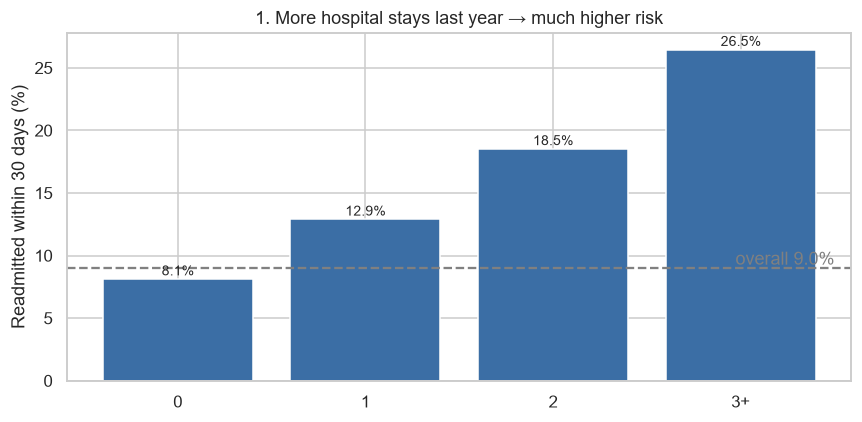

,prior_inpatient_group,patients,rate
0,0,61782,8.117251
1,1,5794,12.892648
2,2,1501,18.520986
3,3+,896,26.450893


In [5]:
BASE = df["is_readmitted_30"].mean() * 100

def rate_chart(column, title, filename, order=None, rotate=0):
    # Bar chart of the readmission rate (%) for each group in `column`.
    # This is the Python version of the SQL pattern:
    #   SELECT column, COUNT(*), 100.0 * SUM(is_readmitted_30) / COUNT(*) ... GROUP BY column

    # 1) one row per group: number of patients + readmission rate
    rates = df.groupby(column)["is_readmitted_30"].agg(["count", "mean"]).reset_index()
    rates.columns = [column, "patients", "rate"]
    rates["rate"] = rates["rate"] * 100              # 0.09 -> 9.0 (%)

    # 2) put the bars in a sensible order
    if order is not None:
        rates = rates.set_index(column).loc[order].reset_index()   # our own order (e.g. ages)
    else:
        rates = rates.sort_values("rate", ascending=False)          # highest rate first

    # 3) draw the chart
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(rates[column].astype(str), rates["rate"], color="#3b6ea5")
    ax.axhline(BASE, linestyle="--", color="grey")                   # the 9.0% baseline
    ax.text(len(rates) - 0.5, BASE + 0.3, f"overall {BASE:.1f}%", ha="right", color="grey")
    for i in range(len(rates)):                                      # write the % on top of each bar
        value = rates["rate"].iloc[i]
        ax.text(i, value + 0.3, f"{value:.1f}%", ha="center", fontsize=9)
    ax.set_title(title)
    ax.set_ylabel("Readmitted within 30 days (%)")
    plt.xticks(rotation=rotate)
    plt.tight_layout()
    fig.savefig(CHARTS / filename)                                   # save for README / deck
    plt.show()
    return rates

rate_chart("prior_inpatient_group", "1. More hospital stays last year → much higher risk",
           "01_prior_stays.png", order=["0", "1", "2", "3+"])

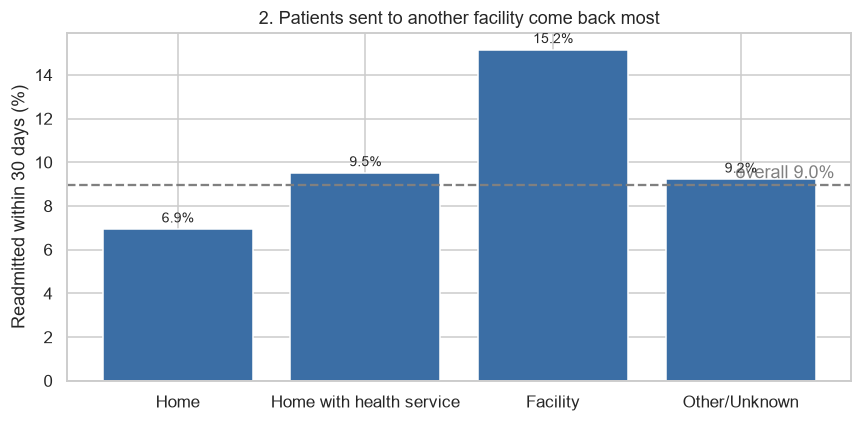

,discharge_group,patients,rate
0,Home,44317,6.945416
1,Home with health service,8362,9.519254
2,Facility,13620,15.154185
3,Other/Unknown,3674,9.227001


In [6]:
rate_chart("discharge_group", "2. Patients sent to another facility come back most",
           "02_discharge.png", order=["Home", "Home with health service", "Facility", "Other/Unknown"])

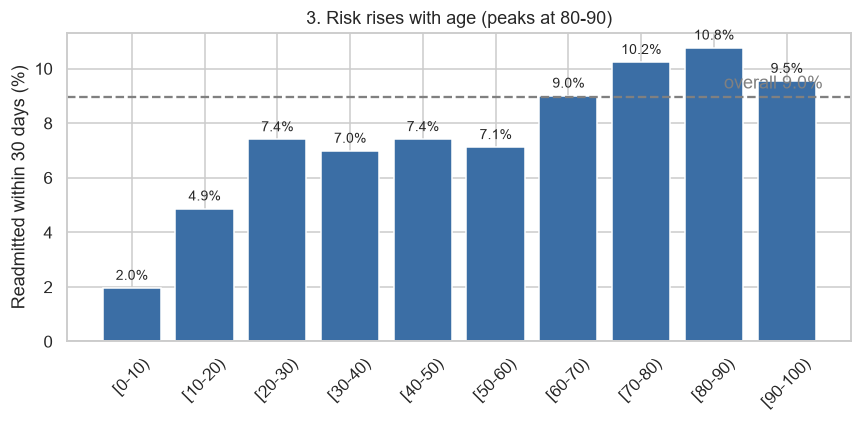

,age,patients,rate
0,[0-10),153,1.960784
1,[10-20),534,4.868914
2,[20-30),1121,7.404103
3,[30-40),2692,6.983655
4,[40-50),6828,7.410662
5,[50-60),12349,7.117985
6,[60-70),15684,9.002805
7,[70-80),17750,10.236620
8,[80-90),11102,10.763826
9,[90-100),1760,9.545455


In [7]:
age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
             "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]
rate_chart("age", "3. Risk rises with age (peaks at 80-90)", "03_age.png", order=age_order, rotate=45)

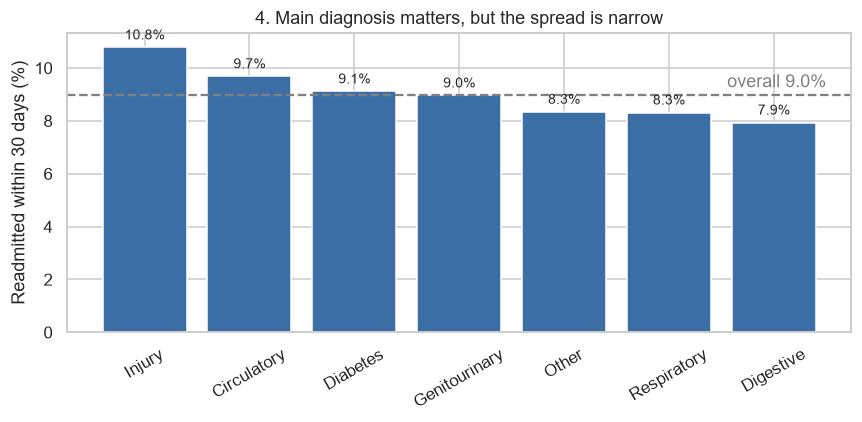

,diag_group,patients,rate
4,Injury,4694,10.779719
0,Circulatory,21316,9.687559
1,Diabetes,5748,9.116214
3,Genitourinary,3414,8.963093
5,Other,22030,8.343168
6,Respiratory,6446,8.315234
2,Digestive,6325,7.936759


In [8]:
rate_chart("diag_group", "4. Main diagnosis matters, but the spread is narrow", "04_diagnosis.png", rotate=30)

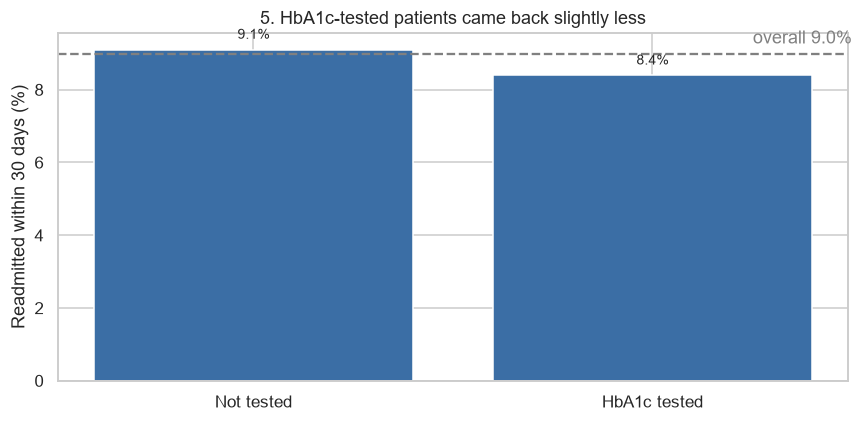

,a1c_label,patients,rate
1,Not tested,57128,9.100616
0,HbA1c tested,12845,8.392371


In [9]:
df["a1c_label"] = df["a1c_tested"].map({1: "HbA1c tested", 0: "Not tested"})
rate_chart("a1c_label", "5. HbA1c-tested patients came back slightly less", "05_a1c_tested.png")

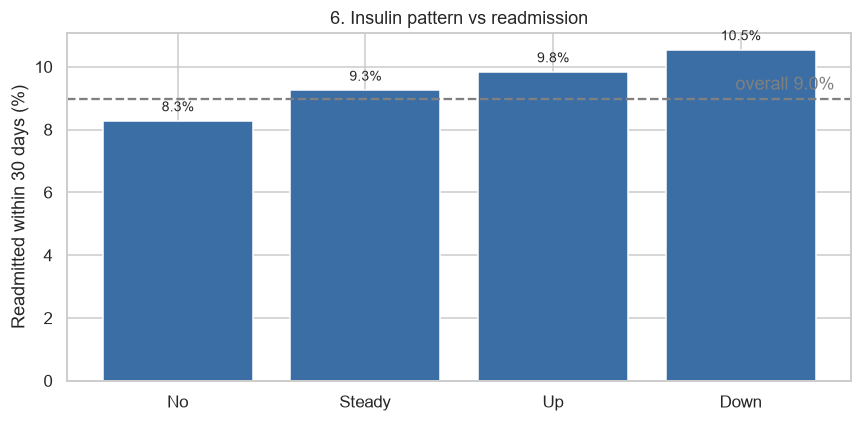

,insulin,patients,rate
0,No,34258,8.281277
1,Steady,21617,9.256604
2,Up,6777,9.842113
3,Down,7321,10.545008


In [10]:
rate_chart("insulin", "6. Insulin pattern vs readmission", "06_insulin.png",
           order=["No", "Steady", "Up", "Down"])

## 4. Chi-square tests — are these differences real or just luck?

**Idea in one line:** the chi-square test compares the counts we *see* with the counts we would *expect if the group made no difference*.

- **p-value < 0.05** → the difference is very unlikely to be luck → **statistically significant**.
- ⚠️ With **70,000 patients, even tiny differences become "significant"**. So we also look at the **size** of the difference (the rates). A difference can be *statistically* significant but *practically* small — a great point to make in an interview.

In [11]:
def chi_square_test(column, label):
    # 0) drop tiny groups (under 100 patients) - a % from 3 patients means nothing
    #    (e.g. gender "Unknown/Invalid" has only a handful of patients)
    group_sizes = df[column].value_counts()
    big_groups = group_sizes[group_sizes >= 100].index
    data = df[df[column].isin(big_groups)]
    # 1) count table: rows = groups, columns = readmitted 0 / 1
    table = pd.crosstab(data[column], data["is_readmitted_30"])
    # 2) the test (we only need the chi-square number and the p-value)
    chi2, p_value, dof, expected = chi2_contingency(table)
    # 3) readmission rate of each group, to see HOW BIG the difference is
    rates = data.groupby(column)["is_readmitted_30"].mean() * 100
    if p_value < 0.001:
        p_text = "< 0.001"
    else:
        p_text = str(round(p_value, 3))
    return {"factor": label,
            "chi_square": round(chi2, 1),
            "p_value": p_text,
            "significant (p<0.05)": "Yes" if p_value < 0.05 else "No",
            "lowest group rate %": round(rates.min(), 1),
            "highest group rate %": round(rates.max(), 1),
            "gap (pct points)": round(rates.max() - rates.min(), 1)}


results = []
results.append(chi_square_test("prior_inpatient_group", "Prior hospital stays (0/1/2/3+)"))
results.append(chi_square_test("discharge_group", "Discharge destination"))
results.append(chi_square_test("age", "Age band"))
results.append(chi_square_test("diag_group", "Main diagnosis group"))
results.append(chi_square_test("insulin", "Insulin pattern"))
results.append(chi_square_test("change", "Medicine changed (Ch/No)"))
results.append(chi_square_test("a1c_tested", "HbA1c tested (yes/no)"))
results.append(chi_square_test("gender", "Gender"))

tests = pd.DataFrame(results).sort_values("chi_square", ascending=False)
tests.to_csv(PBI / "chi_square_results.csv", index=False)
tests

,factor,chi_square,p_value,significant (p<0.05),lowest group rate %,highest group rate %,gap (pct points)
1,Discharge destination,863.7,< 0.001,Yes,6.9,15.2,8.2
0,Prior hospital stays (0/1/2/3+),667.2,< 0.001,Yes,8.1,26.5,18.3
2,Age band,188.1,< 0.001,Yes,2.0,10.8,8.8
3,Main diagnosis group,54.7,< 0.001,Yes,7.9,10.8,2.8
4,Insulin pattern,50.6,< 0.001,Yes,8.3,10.5,2.3
5,Medicine changed (Ch/No),15.0,< 0.001,Yes,8.6,9.4,0.8
6,HbA1c tested (yes/no),6.4,0.012,Yes,8.4,9.1,0.7
7,Gender,0.3,0.583,No,8.9,9.0,0.1


**How to read it:** prior hospital stays has by far the biggest chi-square and gap → strongest factor. Factors like HbA1c testing or medicine change are *significant* but the gap is under 1–2 percentage points → real, but small.

## 5. Machine learning — simple and explainable

**Goal:** give every patient a **risk score** (probability of coming back within 30 days).

**Two models:**
1. **Logistic Regression** — main model. Simple, and gives **odds ratios** ("how much does each factor raise the risk?").
2. **Random Forest** — comparison model. Many decision trees voting together; can catch non-linear patterns.

**Key choices (be ready to explain each):**
- **Stratified train/test split (75/25):** the model learns on 75%, is graded on the unseen 25%. `stratify` keeps the 9% readmission share in both parts.
- **`class_weight="balanced"`:** only 9% are readmitted. Without this, the model gets lazy and predicts "No" for everyone (91% accuracy, catches nobody). Balanced weights make each missed readmission "cost" more.
- **One-hot encoding with a reference group:** each category becomes a 0/1 column; one group per column is the *reference* (e.g. *Home* for discharge), so odds ratios read as "compared with patients sent home".
- **No scaling:** numbers stay in real units, so an odds ratio means "per 1 extra hospital stay", which is easy to explain.

In [12]:
NUMERIC = ["age_midpoint", "time_in_hospital", "num_lab_procedures", "num_procedures",
           "num_medications", "number_outpatient", "number_emergency", "number_inpatient",
           "number_diagnoses", "a1c_tested"]

# For each category column: the FIRST value in the list is the reference group
CATEGORIES = {
    "gender":                 ["Female", "Male", "Unknown/Invalid"],
    "race":                   ["Caucasian", "AfricanAmerican", "Hispanic", "Asian", "Other", "Unknown"],
    "admission_type_group":   ["Elective", "Emergency", "Urgent", "Other/Unknown"],
    "admission_source_group": ["Referral", "Emergency room", "Transfer", "Other/Unknown"],
    "discharge_group":        ["Home", "Home with health service", "Facility", "Other/Unknown"],
    "diag_group":             ["Other", "Diabetes", "Circulatory", "Respiratory", "Digestive", "Genitourinary", "Injury"],
    "insulin":                ["No", "Steady", "Up", "Down"],
    "metformin":              ["No", "Steady", "Up", "Down"],
    "change":                 ["No", "Ch"],
    "diabetesMed":            ["No", "Yes"],
}
CATEGORICAL = list(CATEGORIES)

X = df[NUMERIC + CATEGORICAL]
y = df["is_readmitted_30"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,} patients ({y_train.mean():.1%} readmitted)")
print(f"Test : {len(X_test):,} patients ({y_test.mean():.1%} readmitted)")

preprocess = ColumnTransformer([
    ("numbers", "passthrough", NUMERIC),
    ("categories", OneHotEncoder(categories=list(CATEGORIES.values()), drop="first"), CATEGORICAL),
])

Train: 52,479 patients (9.0% readmitted)
Test : 17,494 patients (9.0% readmitted)


In [13]:
log_reg = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(class_weight="balanced", max_iter=5000)),
])
forest = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=50,
                                     class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
])
log_reg.fit(X_train, y_train)
forest.fit(X_train, y_train)
print("Both models trained ✅")

Both models trained ✅


### 5a. How good are the models? (graded on the 25% test set they never saw)

| Metric | Simple meaning |
|---|---|
| **AUC** | If you pick one readmitted and one non-readmitted patient at random, how often does the model give the readmitted one a higher score? 0.5 = coin flip, 1.0 = perfect. |
| **Recall** | Of the patients who really came back, what % did the model flag? *(most important here)* |
| **Precision** | Of the patients the model flagged, what % really came back? |
| **Accuracy** | % of all predictions correct — **misleading here** (see the "always No" row). |

In [14]:
def evaluate(name, model):
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return {"model": name,
            "AUC": round(roc_auc_score(y_test, prob), 3),
            "recall": round(recall_score(y_test, pred), 3),
            "precision": round(precision_score(y_test, pred), 3),
            "F1": round(f1_score(y_test, pred), 3),
            "accuracy": round(accuracy_score(y_test, pred), 3)}

always_no = {"model": "Lazy baseline: always predict 'No'", "AUC": 0.5, "recall": 0.0,
             "precision": 0.0, "F1": 0.0, "accuracy": round(1 - y_test.mean(), 3)}
metrics = pd.DataFrame([evaluate("Logistic Regression", log_reg),
                        evaluate("Random Forest", forest), always_no])
metrics.to_csv(PBI / "model_metrics.csv", index=False)
metrics

,model,AUC,recall,precision,F1,accuracy
0,Logistic Regression,0.638,0.526,0.137,0.218,0.661
1,Random Forest,0.638,0.543,0.137,0.219,0.653
2,Lazy baseline: always predict 'No',0.500,0.000,0.000,0.000,0.910


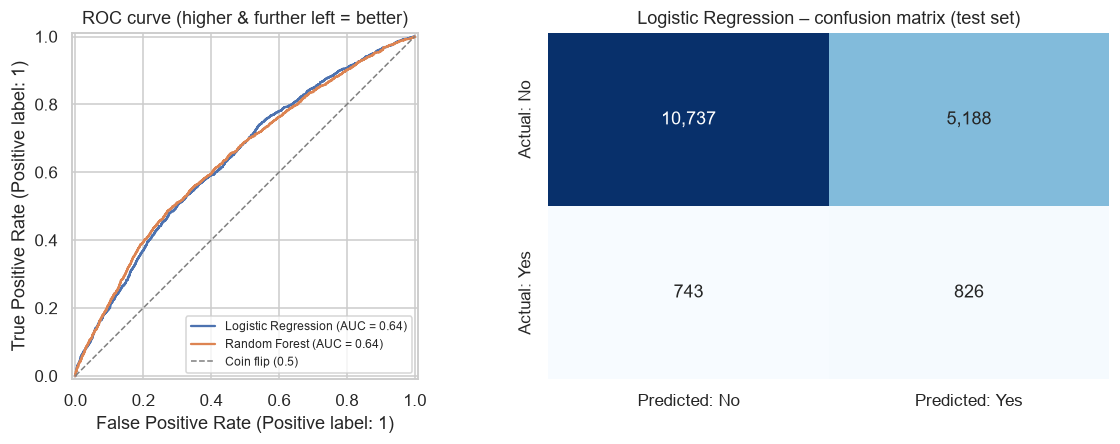

Caught 826 of 1,569 readmitted patients (recall 53%); 5,188 false alarms.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
RocCurveDisplay.from_estimator(log_reg, X_test, y_test, ax=axes[0], name="Logistic Regression")
RocCurveDisplay.from_estimator(forest, X_test, y_test, ax=axes[0], name="Random Forest")
axes[0].plot([0, 1], [0, 1], ls="--", color="grey", lw=1, label="Coin flip (0.5)")
axes[0].set_title("ROC curve (higher & further left = better)")
axes[0].legend(fontsize=8)

cm = confusion_matrix(y_test, log_reg.predict(X_test))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=False, ax=axes[1],
            xticklabels=["Predicted: No", "Predicted: Yes"], yticklabels=["Actual: No", "Actual: Yes"])
axes[1].set_title("Logistic Regression – confusion matrix (test set)")
plt.tight_layout()
fig.savefig(CHARTS / "07_roc_confusion.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Caught {tp:,} of {tp + fn:,} readmitted patients (recall {tp/(tp+fn):.0%}); "
      f"{fp:,} false alarms.")

**How to talk about these results honestly:**
- AUC around **0.6–0.65** is **normal for this dataset** — published studies on it report similar values (about 0.64–0.67).
- Readmission depends on things **not in the data**: does the patient take their medicine at home, have family support, eat well, keep follow-up appointments?
- Random Forest is **not much better** than Logistic Regression → the simple model is enough, and it is easier to explain. *(Choosing the simpler model when results are similar is a mature decision.)*
- The goal is not a perfect prediction — it is to **rank** patients so a limited budget goes to the riskiest ones (Part 7).

## 6. Why is a patient high-risk? — odds ratios + feature importance

**Odds ratio (OR)** = `exp(coefficient)` from the logistic regression.
- **OR = 1.0** → no effect
- **OR = 1.30** → 30% higher odds of readmission
- **OR = 0.80** → 20% lower odds

For numbers it is **per 1 unit** (e.g. per 1 extra hospital stay). For categories it is **compared with the reference group** (e.g. *Facility* vs *Home*). All other factors are held equal — that is the big advantage over the simple SQL tables.

In [16]:
# 1) names of the columns the model actually used (after one-hot encoding)
feature_names = log_reg.named_steps["prep"].get_feature_names_out()
# 2) one coefficient per column
coefficients = log_reg.named_steps["model"].coef_[0]

odds = pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
# 3) odds ratio = e ^ coefficient
odds["odds_ratio"] = np.exp(odds["coefficient"]).round(3)
# 4) clean the names: "categories__discharge_group_Facility" -> "discharge_group_Facility"
odds["feature"] = odds["feature"].str.replace("numbers__", "").str.replace("categories__", "")


# 5) plain-English effect: 1.30 -> "+30% odds", 0.80 -> "-20% odds"
def describe_effect(odds_ratio):
    change = round((odds_ratio - 1) * 100)
    if change >= 0:
        return f"+{change}% odds"
    return f"{change}% odds"


odds["effect"] = odds["odds_ratio"].apply(describe_effect)
odds = odds.sort_values("odds_ratio", ascending=False)
odds.to_csv(PBI / "odds_ratios.csv", index=False)
odds[["feature", "odds_ratio", "effect"]].head(12)        # the 12 factors that RAISE risk most

,feature,odds_ratio,effect
24,discharge_group_Facility,2.186,+119% odds
7,number_inpatient,1.443,+44% odds
25,discharge_group_Other/Unknown,1.435,+44% odds
23,discharge_group_Home with health service,1.305,+30% odds
27,diag_group_Circulatory,1.260,+26% odds
39,diabetesMed_Yes,1.254,+25% odds
37,metformin_Down,1.216,+22% odds
6,number_emergency,1.171,+17% odds
26,diag_group_Diabetes,1.169,+17% odds
17,admission_type_group_Emergency,1.129,+13% odds


In [17]:
odds[["feature", "odds_ratio", "effect"]].tail(8)         # the 8 factors that LOWER risk most

,feature,odds_ratio,effect
16,race_Unknown,0.938,-6% odds
35,metformin_Steady,0.920,-8% odds
22,admission_source_group_Other/Unknown,0.904,-10% odds
15,race_Other,0.891,-11% odds
20,admission_source_group_Emergency room,0.881,-12% odds
9,a1c_tested,0.876,-12% odds
21,admission_source_group_Transfer,0.752,-25% odds
36,metformin_Up,0.743,-26% odds


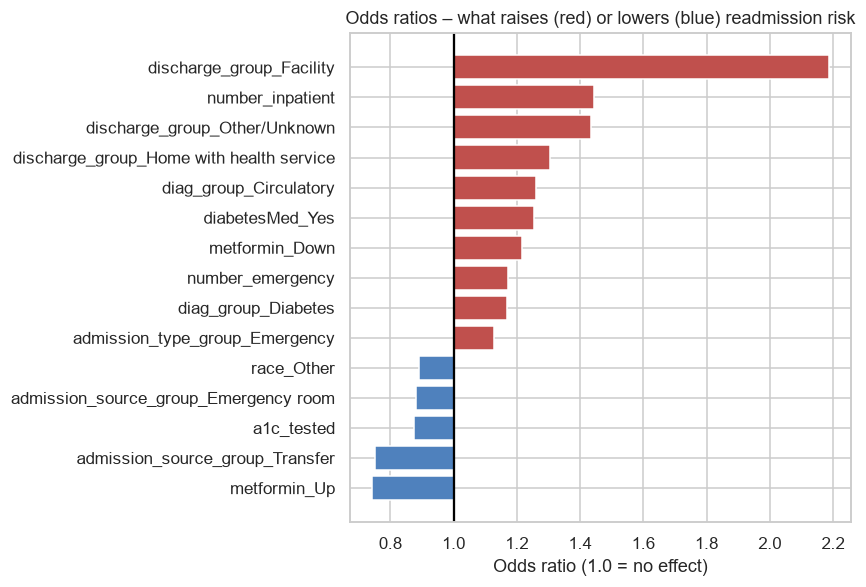

In [18]:
# Chart: the 15 factors with the biggest effect.
# "Biggest effect" = furthest from 1.0 in either direction, so we use the size of the coefficient.
odds["effect_size"] = odds["coefficient"].abs()
top = odds.sort_values("effect_size", ascending=False).head(15)
top = top.sort_values("odds_ratio")                      # smallest at the bottom of the chart

colors = []
for value in top["odds_ratio"]:
    if value > 1:
        colors.append("#c0504d")                         # red = raises risk
    else:
        colors.append("#4f81bd")                         # blue = lowers risk

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top["feature"], top["odds_ratio"] - 1, left=1, color=colors)   # bars start at 1.0
ax.axvline(1, color="black")
ax.set_title("Odds ratios – what raises (red) or lowers (blue) readmission risk")
ax.set_xlabel("Odds ratio (1.0 = no effect)")
plt.tight_layout()
fig.savefig(CHARTS / "08_odds_ratios.png")
plt.show()

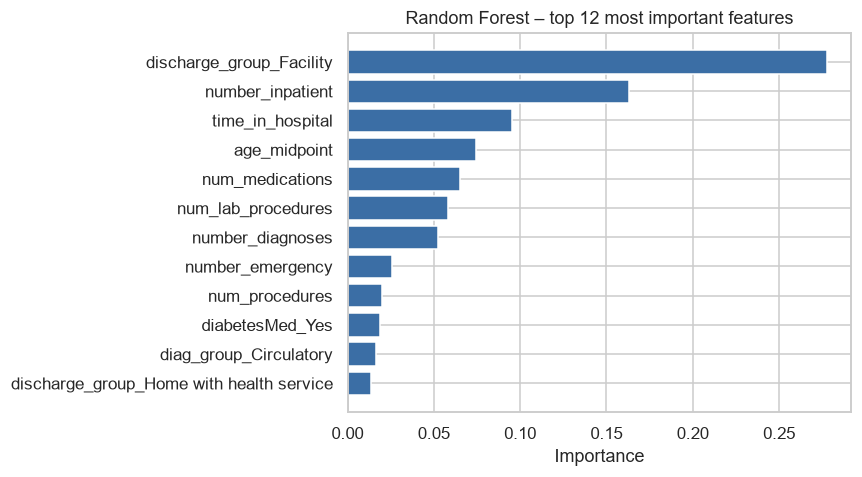

In [19]:
# Random Forest feature importance (how much each column helped the trees make good splits)
rf_names = forest.named_steps["prep"].get_feature_names_out()
rf_values = forest.named_steps["model"].feature_importances_

importance = pd.DataFrame({"feature": rf_names, "importance": rf_values})
importance["feature"] = importance["feature"].str.replace("numbers__", "").str.replace("categories__", "")
importance = importance.sort_values("importance", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(importance["feature"][::-1], importance["importance"][::-1], color="#3b6ea5")  # [::-1] = biggest on top
ax.set_title("Random Forest – top 12 most important features")
ax.set_xlabel("Importance")
plt.tight_layout()
fig.savefig(CHARTS / "09_rf_importance.png")
plt.show()

**Both models agree on the top two drivers:** **discharge to a facility** and **prior hospital stays** are #1 and #2 in *both* charts. When two very different models agree, we can trust the story more.

*Notes for the interview:*
- Random Forest importance says **how useful** a column was, but not **in which direction** (up or down). That is why the odds ratios are the main explanation.
- Random Forest importance is known to **favour number columns with many different values** (time in hospital, age, number of medicines) because they offer more possible split points. So their high ranking there should be read with care.
- In the odds-ratio chart, number columns like `num_medications` look small because their odds ratio is **per 1 unit** (one extra medicine) — small per unit, but it adds up.

## 7. Risk deciles + gains chart — the pharma targeting view

**Steps:**
1. Score every test patient with the logistic regression.
2. Sort from highest to lowest risk.
3. Cut into **10 equal groups (deciles)**. Decile 1 = riskiest 10%.
4. Count how many of the **real** readmissions fall in each decile.

This is exactly how pharma companies decide **which doctors or patients to target first**. It also solves the NTILE problem from SQL file 03: the score uses many columns, so there are no big ties.

In [20]:
def add_deciles(table):
    # Sort patients from highest to lowest risk, then cut into 10 equal groups.
    # Patient number 0 .. N-1 in that order -> decile = (position * 10 // N) + 1
    # so the first 10% get decile 1, the next 10% decile 2, ... the last 10% decile 10.
    # (Same idea as SQL: NTILE(10) OVER (ORDER BY risk_score DESC))
    table = table.sort_values("risk_score", ascending=False).copy()
    position = np.arange(len(table))                 # 0, 1, 2, ..., N-1
    table["decile"] = position * 10 // len(table) + 1
    return table


test = X_test.copy()
test["actual"] = y_test.values                                   # real outcome (0/1)
test["risk_score"] = log_reg.predict_proba(X_test)[:, 1]         # model's probability of readmission
test = add_deciles(test)

# One row per decile (same as SQL: GROUP BY decile)
deciles = test.groupby("decile").agg(patients=("actual", "count"),
                                     readmissions=("actual", "sum"),
                                     avg_risk_score=("risk_score", "mean")).reset_index()

overall_rate = test["actual"].mean() * 100
total_readmissions = deciles["readmissions"].sum()

deciles["readmission_rate_pct"] = (100 * deciles["readmissions"] / deciles["patients"]).round(1)
deciles["pct_of_all_readmissions"] = (100 * deciles["readmissions"] / total_readmissions).round(1)
deciles["cumulative_pct_readmissions"] = deciles["pct_of_all_readmissions"].cumsum().round(1)   # running total
deciles["cumulative_pct_patients"] = deciles["decile"] * 10
deciles["lift"] = (deciles["readmission_rate_pct"] / overall_rate).round(2)   # 2.0 = twice the average
deciles.to_csv(PBI / "decile_summary.csv", index=False)
deciles

,decile,patients,readmissions,avg_risk_score,readmission_rate_pct,pct_of_all_readmissions,cumulative_pct_readmissions,cumulative_pct_patients,lift
0,1,1750,296,0.704532,16.9,18.9,18.9,10,1.88
1,2,1749,250,0.611084,14.3,15.9,34.8,20,1.59
2,3,1750,212,0.549834,12.1,13.5,48.3,30,1.35
3,4,1749,150,0.497483,8.6,9.6,57.9,40,0.96
4,5,1749,146,0.460673,8.3,9.3,67.2,50,0.93
5,6,1750,153,0.433937,8.7,9.8,77.0,60,0.97
6,7,1749,112,0.410129,6.4,7.1,84.1,70,0.71
7,8,1750,101,0.386535,5.8,6.4,90.5,80,0.65
8,9,1749,86,0.361695,4.9,5.5,96.0,90,0.55
9,10,1749,63,0.320649,3.6,4.0,100.0,100,0.40


In [21]:
top2 = deciles.loc[deciles["decile"] <= 2, "pct_of_all_readmissions"].sum()
top1_lift = deciles.loc[0, "lift"]
print(f"Top 20% riskiest patients contain {top2:.1f}% of all readmissions "
      f"(random targeting would give 20%).")
print(f"Decile 1 is {top1_lift}x the average readmission rate.")
print("Compare with the simple SQL rule (file 04, F8): its 'High' tier held 4.6% of patients "
      "and only 10.2% of readmissions.")

Top 20% riskiest patients contain 34.8% of all readmissions (random targeting would give 20%).
Decile 1 is 1.88x the average readmission rate.
Compare with the simple SQL rule (file 04, F8): its 'High' tier held 4.6% of patients and only 10.2% of readmissions.


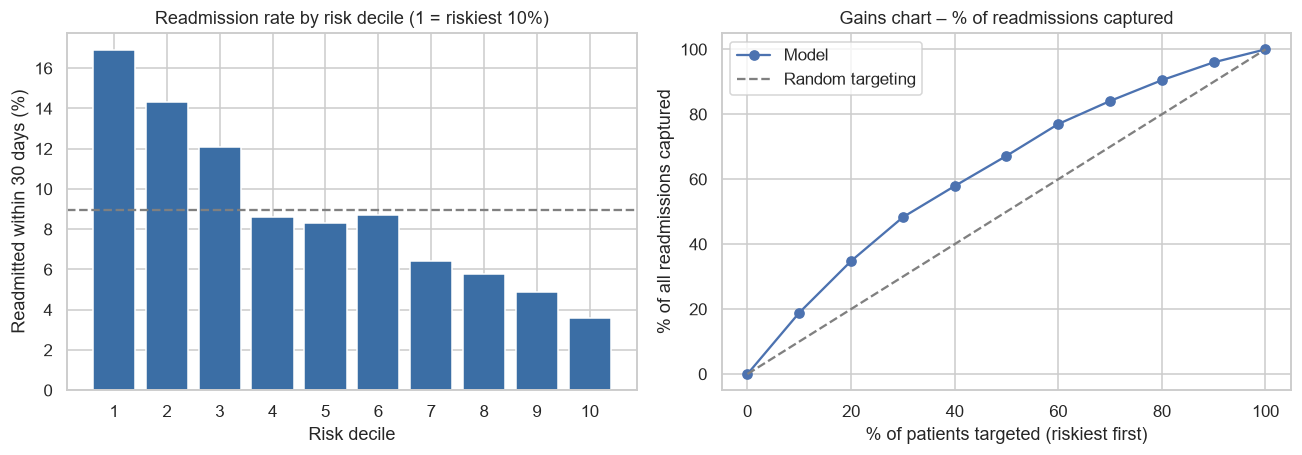

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

# Left: readmission rate in each decile
axes[0].bar(deciles["decile"].astype(str), deciles["readmission_rate_pct"], color="#3b6ea5")
axes[0].axhline(overall_rate, linestyle="--", color="grey")
axes[0].set_title("Readmission rate by risk decile (1 = riskiest 10%)")
axes[0].set_xlabel("Risk decile")
axes[0].set_ylabel("Readmitted within 30 days (%)")

# Right: gains chart. Start both lines at (0, 0).
x_points = [0] + list(deciles["cumulative_pct_patients"])
y_points = [0] + list(deciles["cumulative_pct_readmissions"])
axes[1].plot(x_points, y_points, marker="o", label="Model")
axes[1].plot([0, 100], [0, 100], linestyle="--", color="grey", label="Random targeting")
axes[1].set_title("Gains chart – % of readmissions captured")
axes[1].set_xlabel("% of patients targeted (riskiest first)")
axes[1].set_ylabel("% of all readmissions captured")
axes[1].legend()

plt.tight_layout()
fig.savefig(CHARTS / "10_deciles_gains.png")
plt.show()

## 8. Business case — is the support programme worth it?

A **what-if model** with clearly labelled **assumptions** (in Power BI these become sliders):

| Assumption | Value | Source / reasoning |
|---|---|---|
| Cost of one readmission | **$15,200** | AHRQ HCUP Statistical Brief #278: average 30-day readmission cost, US 2018 |
| Programme cost per patient | **$300** | *Assumption*: ~2 nurse calls + 1 pharmacist medicine review |
| Readmissions prevented | **20%** of the targeted group's readmissions | *Assumption* — vary it (10–30%) in the sensitivity table |

**Formula (per scenario):**
`Savings = readmissions in targeted group × 20% × $15,200`
`Cost = patients targeted × $300`
`Net benefit = Savings − Cost` and `ROI = Net benefit ÷ Cost`

Numbers are scaled to **10,000 patients** so they are easy to read.

In [23]:
COST_PER_READMISSION = 15_200
PROGRAMME_COST_PER_PATIENT = 300
PREVENTION_RATE = 0.20
POPULATION = 10_000

def roi_for_top(pct_targeted, prevention=PREVENTION_RATE, cost_per_patient=PROGRAMME_COST_PER_PATIENT):
    # 1) take the riskiest X% of test patients (test is already sorted, riskiest first)
    n_targeted = int(len(test) * pct_targeted / 100)
    targeted = test.head(n_targeted)

    # 2) scale the test-set numbers up to a population of 10,000 patients
    scale = POPULATION / len(test)
    patients = n_targeted * scale
    readmissions = targeted["actual"].sum() * scale

    # 3) the business formulas
    prevented = readmissions * prevention
    savings = prevented * COST_PER_READMISSION
    cost = patients * cost_per_patient
    net_benefit = savings - cost
    roi_pct = 100 * net_benefit / cost

    return {"pct_targeted": pct_targeted,
            "patients_targeted": round(patients),
            "readmissions_in_group": round(readmissions),
            "readmissions_prevented": round(prevented),
            "savings_$": round(savings),
            "programme_cost_$": round(cost),
            "net_benefit_$": round(net_benefit),
            "ROI_%": round(roi_pct, 1)}


scenarios = []
for pct in [10, 20, 30, 50, 100]:
    scenarios.append(roi_for_top(pct))
roi = pd.DataFrame(scenarios)
roi.to_csv(PBI / "roi_scenarios.csv", index=False)
roi

,pct_targeted,patients_targeted,readmissions_in_group,readmissions_prevented,savings_$,programme_cost_$,net_benefit_$,ROI_%
0,10,1000,169,34,514371,299931,214439,71.5
1,20,2000,312,62,948805,599863,348942,58.2
2,30,3000,433,87,1317206,899966,417240,46.4
3,50,5000,602,120,1831577,1500000,331577,22.1
4,100,10000,897,179,2726512,3000000,-273488,-9.1


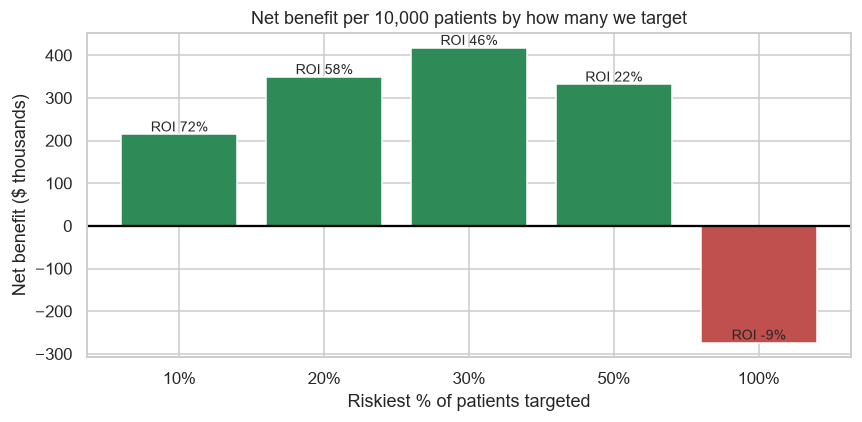

In [24]:
labels = roi["pct_targeted"].astype(str) + "%"
values = roi["net_benefit_$"] / 1000                      # show in $ thousands
colors = []
for v in values:
    if v > 0:
        colors.append("#2e8b57")                          # green = makes money
    else:
        colors.append("#c0504d")                          # red = loses money

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, values, color=colors)
ax.axhline(0, color="black")
for i in range(len(roi)):
    ax.text(i, values.iloc[i], f"ROI {roi['ROI_%'].iloc[i]:.0f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("Net benefit per 10,000 patients by how many we target")
ax.set_xlabel("Riskiest % of patients targeted")
ax.set_ylabel("Net benefit ($ thousands)")
plt.tight_layout()
fig.savefig(CHARTS / "11_roi.png")
plt.show()

In [25]:
# Sensitivity: how does net benefit change if our assumptions are wrong?
rows = []
for prevention in [0.10, 0.15, 0.20, 0.25, 0.30]:          # 10% ... 30% of readmissions prevented
    row = {"readmissions_prevented": f"{prevention:.0%}"}
    for pct in [10, 20, 30, 50, 100]:                       # how many patients we target
        result = roi_for_top(pct, prevention=prevention)
        row[f"target top {pct}%"] = result["net_benefit_$"]
    rows.append(row)
sensitivity = pd.DataFrame(rows).set_index("readmissions_prevented")
sensitivity.to_csv(PBI / "roi_sensitivity.csv")
print("Net benefit in $ per 10,000 patients (programme cost $300 per patient):")
sensitivity

Net benefit in $ per 10,000 patients (programme cost $300 per patient):


,target top 10%,target top 20%,target top 30%,target top 50%,target top 100%
readmissions_prevented,,,,,
10%,-42746,-125460,-241363,-584212,-1636744
15%,85847,111741,87939,-126318,-955116
20%,214439,348942,417240,331577,-273488
25%,343032,586144,746542,789471,408140
30%,471625,823345,1075843,1247365,1089768


In [26]:
# Break-even: what prevention rate makes each strategy pay for itself?
for pct in [10, 20, 50, 100]:
    r = roi_for_top(pct)
    breakeven = r["programme_cost_$"] / (r["readmissions_in_group"] * COST_PER_READMISSION)
    print(f"Target top {pct:>3}%: programme must prevent at least {breakeven:.0%} of the group's readmissions to break even")

Target top  10%: programme must prevent at least 12% of the group's readmissions to break even
Target top  20%: programme must prevent at least 13% of the group's readmissions to break even
Target top  50%: programme must prevent at least 16% of the group's readmissions to break even
Target top 100%: programme must prevent at least 22% of the group's readmissions to break even


**So-what (read the table and chart above):**
- **Targeting everyone loses money** at a 20% success rate — it needs about 22% to break even, while targeting the top 10–20% breaks even at about 12–13%.
- **ROI % is highest for the top 10%** (every dollar works hardest), but **total net benefit is highest around the top 30%** (more patients helped while still profitable). Which one to pick depends on the client's goal: *limited budget → top 10–20%; maximise total savings → top 30%.*
- The risk score lets the client spend the **same budget where it saves the most** — the core recommendation of this project.

## 9. Re-testing the original 2014 study (HbA1c)

The dataset comes from **Strack et al., 2014** (*BioMed Research International*), which studied whether **measuring HbA1c** in hospital is linked to **lower readmission**.

We check it two ways:
1. **Simple comparison + chi-square** (no other factors considered).
2. **Adjusted** — the odds ratio of `a1c_tested` from our logistic regression, which holds age, prior stays, diagnosis, discharge, etc. constant.

In [27]:
# 1) simple comparison (same as SQL F5)
a1c = df.groupby("a1c_label")["is_readmitted_30"].agg(["count", "mean"])
a1c.columns = ["patients", "rate"]
a1c["rate"] = (a1c["rate"] * 100).round(2)
print(a1c, "\n")

# 2) is the difference real? (chi-square test)
table = pd.crosstab(df["a1c_tested"], df["is_readmitted_30"])
chi2, p_value, dof, expected = chi2_contingency(table)
print(f"Chi-square p-value: {p_value:.4f}")

# 3) adjusted effect: the odds ratio of a1c_tested from the logistic regression
or_a1c = odds[odds["feature"] == "a1c_tested"]["odds_ratio"].iloc[0]
print(f"Adjusted odds ratio for HbA1c tested: {or_a1c:.3f}  (below 1.0 = lower risk)")

              patients  rate
a1c_label                   
HbA1c tested     12845  8.39
Not tested       57128  9.10 

Chi-square p-value: 0.0117
Adjusted odds ratio for HbA1c tested: 0.876  (below 1.0 = lower risk)


In [28]:
# The study's key idea: testing helps when the doctor ACTS on it (changes medicine)
# Same as SQL F6: rows = tested / not tested, columns = medicine changed or not, values = rate %
combo = df.groupby(["a1c_label", "change"])["is_readmitted_30"].mean().unstack() * 100
combo = combo.round(1)
combo.columns = ["Medicine changed (Ch)", "No change"]
combo

,Medicine changed (Ch),No change
a1c_label,,
HbA1c tested,8.6,8.1
Not tested,9.7,8.7


**Conclusion to say in an interview:** *"Tested patients came back slightly less often, and the effect stayed after controlling for other factors — the same direction as the original study. But the effect is small (under 1 percentage point) and it is a correlation: hospitals that test HbA1c may also give better care in general. The practical message is cheap and clear: test HbA1c before changing diabetes medicines."*

## 10. Treatment patterns — the pharma lens

Pharma companies ask: **how are patients treated, and how do they do?** (a mini *patient-journey* view)

In [29]:
# Same as SQL F7 (treatment combination)
treat = df.groupby("treatment_group")["is_readmitted_30"].agg(["count", "mean"]).reset_index()
treat.columns = ["treatment_group", "patients", "readmission_rate_pct"]
treat["readmission_rate_pct"] = (treat["readmission_rate_pct"] * 100).round(1)
treat["pct_of_patients"] = (100 * treat["patients"] / treat["patients"].sum()).round(1)
treat = treat.sort_values("readmission_rate_pct", ascending=False)
treat.to_csv(PBI / "treatment_patterns.csv", index=False)
display(treat)

# Insulin pattern inside each age band (rows = age, columns = insulin status, values = rate %)
insulin_by_age = df.groupby(["age", "insulin"])["is_readmitted_30"].mean().unstack() * 100
insulin_by_age = insulin_by_age[["No", "Steady", "Up", "Down"]].round(1)
display(insulin_by_age)

,treatment_group,patients,readmission_rate_pct,pct_of_patients
0,Insulin only,28417,9.9,40.6
1,Metformin + Insulin,7298,8.5,10.4
3,Neither,26653,8.3,38.1
2,Metformin only,7605,8.1,10.9


insulin,No,Steady,Up,Down
age,,,,
[0-10),0.0,2.1,5.3,0.0
[10-20),3.4,5.6,6.2,2.4
[20-30),6.2,6.8,8.5,9.2
[30-40),6.1,6.7,7.0,10.3
[40-50),6.2,8.0,8.5,9.2
[50-60),6.5,7.5,7.6,8.1
[60-70),8.2,9.0,11.0,10.6
[70-80),9.7,10.3,11.8,12.0
[80-90),9.7,11.8,10.5,14.0


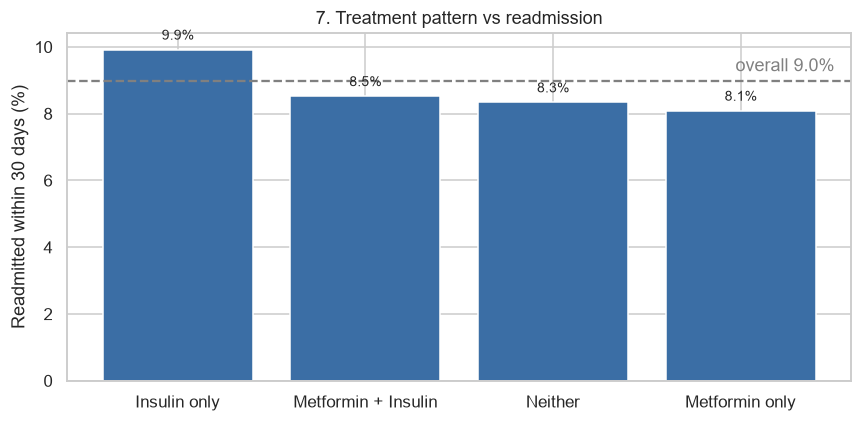

,treatment_group,patients,rate
0,Insulin only,28417,9.916599
1,Metformin + Insulin,7298,8.522883
3,Neither,26653,8.336773
2,Metformin only,7605,8.086785


In [30]:
rate_chart("treatment_group", "7. Treatment pattern vs readmission", "12_treatment.png")

**Reading it carefully:** patients on **insulin without metformin** come back most. This does **not** mean insulin is harmful — doctors give insulin to patients with more advanced diabetes or kidney problems (where metformin cannot be used). This is **confounding**: a hidden third factor (how sick the patient is) drives both the treatment and the outcome.

## 11. Export files for the Power BI dashboard

`patients_scored.csv` has **every patient** with readable columns + risk score + risk decile.
*Note:* the model was trained on 75% of these patients, so scores for those patients are slightly optimistic. All **model-quality numbers** above come only from the 25% test set; the dashboard uses scores just to **rank and segment**.

In [31]:
# 1) risk score for every patient
df["risk_score"] = log_reg.predict_proba(df[NUMERIC + CATEGORICAL])[:, 1].round(4)

# 2) risk decile for every patient (same helper as in Part 7)
df = add_deciles(df)
df = df.rename(columns={"decile": "risk_decile"})


# 3) simple risk tier from the decile
def risk_tier(decile):
    if decile <= 2:
        return "High (top 20%)"
    elif decile <= 5:
        return "Medium (next 30%)"
    else:
        return "Low (bottom 50%)"


df["risk_tier"] = df["risk_decile"].apply(risk_tier)

export_cols = ["patient_nbr", "encounter_id", "age", "age_midpoint", "gender", "race",
               "admission_type_group", "admission_source_group", "discharge_group", "diag_1", "diag_group",
               "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
               "number_outpatient", "number_emergency", "number_inpatient", "prior_inpatient_group",
               "number_diagnoses", "A1Cresult", "a1c_tested", "insulin", "metformin", "treatment_group",
               "change", "diabetesMed", "readmitted", "is_readmitted_30",
               "risk_score", "risk_decile", "risk_tier"]
df[export_cols].to_csv(PBI / "patients_scored.csv", index=False)
df[export_cols].to_csv(PROCESSED / "diabetic_data_clean.csv", index=False)

# Top 100 riskiest patients = the "call list" for the support programme
df.nlargest(100, "risk_score")[["patient_nbr", "age", "discharge_group", "number_inpatient",
                                "number_emergency", "number_diagnoses", "diag_group",
                                "risk_score"]].to_csv(PBI / "top100_call_list.csv", index=False)

print("Exported files:")
for f in sorted(PBI.glob("*.csv")):
    print(f"  {f.name:<28} {len(pd.read_csv(f)):>7,} rows")

Exported files:
  chi_square_results.csv             8 rows
  decile_summary.csv                10 rows
  model_metrics.csv                  3 rows
  odds_ratios.csv                   40 rows


  patients_scored.csv           69,973 rows
  roi_scenarios.csv                  5 rows
  roi_sensitivity.csv                5 rows
  top100_call_list.csv             100 rows
  treatment_patterns.csv             4 rows


## 12. Summary — the numbers for your deck, README and resume

In [32]:
lr_auc = metrics["AUC"].iloc[0]
rf_auc = metrics["AUC"].iloc[1]
lr_recall = metrics["recall"].iloc[0]
best = roi.sort_values("net_benefit_$", ascending=False).iloc[0]          # best ROI scenario
inpatient_or = odds[odds["feature"] == "number_inpatient"]["odds_ratio"].iloc[0]
facility_or = odds[odds["feature"] == "discharge_group_Facility"]["odds_ratio"].iloc[0]

print("DATA      :", f"{len(df):,} patients,", f"{df['is_readmitted_30'].mean():.1%} readmitted within 30 days")
print("STRONGEST : prior hospital stays -> 8.1% (0 stays) to 26.5% (3+ stays);",
      f"odds ratio {inpatient_or:.2f} per extra stay")
print("DISCHARGE :", f"facility vs home odds ratio {facility_or:.2f}")
print("MODEL     :", f"Logistic Regression AUC {lr_auc}, Random Forest AUC {rf_auc}, recall {lr_recall:.0%}")
print("TARGETING :", f"top 20% riskiest patients hold {top2:.1f}% of readmissions (random = 20%)")
print("BUSINESS  :", f"biggest net benefit = target top {int(best['pct_targeted'])}% ->",
      f"${int(best['net_benefit_$']):,} per 10,000 patients (ROI {best['ROI_%']:.0f}%);",
      "targeting everyone loses money")
print("HbA1c     :", f"tested {a1c.loc['HbA1c tested', 'rate']}% vs not tested {a1c.loc['Not tested', 'rate']}%;",
      f"adjusted OR {or_a1c:.2f}")

DATA      : 69,973 patients, 9.0% readmitted within 30 days
STRONGEST : prior hospital stays -> 8.1% (0 stays) to 26.5% (3+ stays); odds ratio 1.44 per extra stay
DISCHARGE : facility vs home odds ratio 2.19
MODEL     : Logistic Regression AUC 0.638, Random Forest AUC 0.638, recall 53%
TARGETING : top 20% riskiest patients hold 34.8% of readmissions (random = 20%)
BUSINESS  : biggest net benefit = target top 30% -> $417,240 per 10,000 patients (ROI 46%); targeting everyone loses money
HbA1c     : tested 8.39% vs not tested 9.1%; adjusted OR 0.88
